# Figure 6.2

This plot compares the TCUSCAN segmented scan versus vector-only baseline segmented scan

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


sns.set_context('paper', font_scale=2., rc={"lines.linewidth": 1.75} )
sns.set_style({'font.weight': 'bold'})

# Markers
plt.rcParams['lines.markersize'] = 6.5
plt.rcParams['lines.linewidth'] = 1.75
plt.rcParams['figure.figsize'] = (8.7,6.27)

_LEGEND_MARKER_SCALE = 1.75
_MARKERS = ["o", "^", "v", "<", ">", "s", "X"]

_SNS_PARAMS = {"markers":_MARKERS, "dashes":True, "markersize": 10}

In [2]:
from glob import glob
from os.path import join

tot_dataframe = pd.concat(map(pd.read_csv, glob(join('./', f"bench_results*_seg_scan_sc_*.csv"))))
tot_dataframe["operator"] = tot_dataframe["operator"].map({ "vec_seg_scan_sc_128": "Vector-only", "seg_scan_sc_128": "MMU+Vector", "baseline_cpu_segscan":"CPU"})

tot_dataframe["benchname"] = tot_dataframe["benchname"].map({"circuit5M": "Circuit5M", "mc2depi": "Epidemiology", "mac_econ_fwd500": "Economics", "ASIC_680k": "ASIC_680k", "pdb1HYS": "Protein"})


In [3]:
tot_dataframe.head(10)

,benchname,operator,dtype,size,time_us
0,Epidemiology,CPU,fp32,2100225.0,1689.00
0,Protein,CPU,fp32,2190591.0,1762.00
0,Protein,MMU+Vector,fp16,NaN,2436.92
0,Economics,MMU+Vector,fp16,NaN,787.30
0,ASIC_680k,Vector-only,fp16,NaN,138758.83
0,Protein,Vector-only,fp16,NaN,155585.57
0,Epidemiology,Vector-only,fp16,NaN,75582.49
0,Circuit5M,CPU,fp32,59524291.0,48065.00
0,Circuit5M,Vector-only,fp16,NaN,2118561.54
0,Economics,Vector-only,fp16,NaN,45779.27


in 15
in 16
in 17


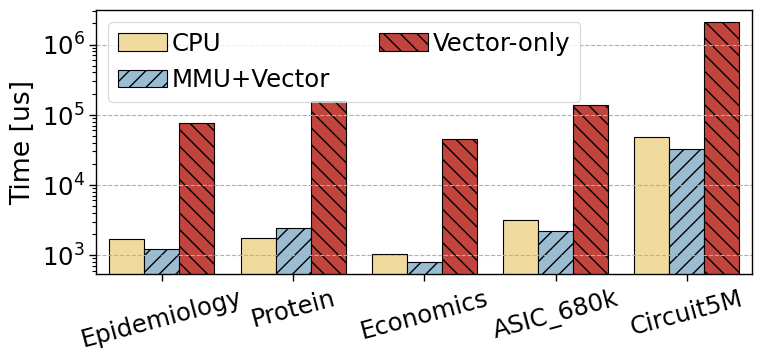

In [21]:
plt.figure(figsize=(8, 4))
### Colorbrewer colors
#d73027
#fc8d59
#fee090
#e0f3f8
#91bfdb
#4575b4
plt.grid(True, linestyle='--')
ax = sns.barplot(data=tot_dataframe, x="benchname", y="time_us", hue="operator", edgecolor="black", palette=["#fee090", "#91bfdb", "#d73027" ])
plt.yscale("log")

plt.xlabel('')
plt.xticks(rotation=15)
plt.ylabel('Time [us]')
# plt.title('Segmented Scan (Single AI Core | S = 128)')
plt.tight_layout()
hatches = ['', '//', '\\\\', 'xx', '++','.']
for i, thisbar in enumerate(ax.patches):
    # print(i)
    if i < 15:
        # Set a different hatch for each bar
        thisbar.set_hatch(hatches[int(i/5)])
    else:
        print(f'in {i}')
        # these are for the legend
        # Note: need to be BEFORE defining the legend!
        thisbar.set_hatch(hatches[i%3])
#plt.grid(True)
plt.legend(loc="upper left", handletextpad=0.2, frameon=True, ncol=2)

plt.savefig("sparsesuite_comparison_latency.png")
plt.savefig("sparsesuite_comparison_latency.pdf",  bbox_inches='tight')
